<a href="https://colab.research.google.com/github/angie05huang/sovereign-credit-rating-prediction/blob/main/Sovereign_Credit_Rating_Reproduction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install + import
!pip install openpyxl
import pandas as pd
from google.colab import files

# Upload file
uploaded = files.upload()
file_path = list(uploaded.keys())[0]

# Check sheet names
xls = pd.ExcelFile(file_path, engine="openpyxl")
print("Sheets:", xls.sheet_names)

# Open the Main sheet WITHOUT assumptions
df = pd.read_excel(file_path, sheet_name="Main", header=None, engine="openpyxl")

# Look at first 20 rows
df.head(20)


Saving Current Sovereign Debt Ratings (includes outlook) (1).xlsm to Current Sovereign Debt Ratings (includes outlook) (1) (1).xlsm
Saving IMF.csv to IMF (1).csv
Saving worldbank.csv to worldbank (1).csv
Sheets: ['Main', 'TreeView_DataCache', 'TreeNodes']


,0,1,2,3,4,5,6,7,8,9,...,114,115,116,117,118,119,120,121,122,123
0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,NaN,NaN,Date of Latest\nUpdate,Outlook,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Customized Ratings,NaN,NaN,NaN
8,NaN,Display Rating Modifiers,No,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Rating Field,RTG_DAGONG_LT_FC_SOVEREIGN,Rating Field,NaN
9,NaN,Last downloaded at 30-Oct-2025 15:42:11,NaN,NaN,NaN,Moody's,NaN,S&P,NaN,Fitch,...,Fitch,NaN,NaN,Fitch (Issuer),NaN,NaN,Date Field,RTG_DAGONG_LT_FC_SOVEREIGN_DT,Date Field,NaN


In [ ]:
# 1. Set correct column names (row 10)
df.columns = df.iloc[10]

# 2. Keep only real data (row 11 onward)
df = df.iloc[11:]

# 3. Reset index
df = df.reset_index(drop=True)

df.head()

10,NaN,Country Name,Ticker,Region,NaN,Outlook,Date,Outlook,Date,Outlook,...,Rating,Date,Score,Rating,Date,Score,Rating,Date,Rating,Date
0,NaN,Abu Dhabi,1022337Z UH Equity,Africa/Middle East,2025-03-20 00:00:00,STABLE,2017-05-25 00:00:00,STABLE,2007-07-02 00:00:00,STABLE,...,NaN,NaN,100,F1+,2007-07-02 00:00:00,2,#NAME?,#NAME?,#NAME?,#NAME?
1,NaN,Albania,1001Z AL Equity,Eastern Europe,2025-03-21 00:00:00,STABLE,2024-10-18 00:00:00,STABLE,2025-03-21 00:00:00,NaN,...,NaN,NaN,100,NaN,NaN,100,#NAME?,#NAME?,#NAME?,#NAME?
2,NaN,Algeria,3700Z US Equity,Africa/Middle East,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,100,NaN,NaN,100,#NAME?,#NAME?,#NAME?,#NAME?
3,NaN,Andorra,1095Z SM Equity,Western Europe,2025-05-09 00:00:00,STABLE,2024-01-19 00:00:00,STABLE,2025-05-09 00:00:00,STABLE,...,NaN,NaN,100,F2,2018-08-10 00:00:00,7,#NAME?,#NAME?,#NAME?,#NAME?
4,NaN,Angola,32272Z AX Equity,Africa/Middle East,2024-11-29 00:00:00,STABLE,2024-11-29 00:00:00,STABLE,2022-02-04 00:00:00,STABLE,...,NaN,NaN,100,B,2022-01-21 00:00:00,11,#NAME?,#NAME?,#NAME?,#NAME?


In [ ]:
import numpy as np
df = df.dropna(how="all")
df = df.dropna(axis=1, how="all")

df = df.replace(["#NAME?", "#VALUE!", "#DIV/0!", "#REF!", "#N/A"], np.nan)

df.columns = (
    df.columns.astype(str)
    .str.strip()
    .str.replace("\n", " ")
    .str.replace(r"\s+", " ", regex=True)
)

df.head()

/tmp/ipykernel_6866/226960465.py:5: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df = df.replace(["#NAME?", "#VALUE!", "#DIV/0!", "#REF!", "#N/A"], np.nan)


10,Country Name,Ticker,Region,nan,Outlook,Date,Outlook,Date,Outlook,Date,...,Rating,Date,Score,Rating,Date,Score,Rating,Date,Rating,Date
0,Abu Dhabi,1022337Z UH Equity,Africa/Middle East,2025-03-20,STABLE,2017-05-25,STABLE,2007-07-02,STABLE,2007-07-02,...,NaN,NaT,100,F1+,2007-07-02,2,NaN,NaN,NaN,NaN
1,Albania,1001Z AL Equity,Eastern Europe,2025-03-21,STABLE,2024-10-18,STABLE,2025-03-21,NaN,NaT,...,NaN,NaT,100,NaN,NaT,100,NaN,NaN,NaN,NaN
2,Algeria,3700Z US Equity,Africa/Middle East,NaT,NaN,NaT,NaN,NaT,NaN,NaT,...,NaN,NaT,100,NaN,NaT,100,NaN,NaN,NaN,NaN
3,Andorra,1095Z SM Equity,Western Europe,2025-05-09,STABLE,2024-01-19,STABLE,2025-05-09,STABLE,2023-10-27,...,NaN,NaT,100,F2,2018-08-10,7,NaN,NaN,NaN,NaN
4,Angola,32272Z AX Equity,Africa/Middle East,2024-11-29,STABLE,2024-11-29,STABLE,2022-02-04,STABLE,2023-06-23,...,NaN,NaT,100,B,2022-01-21,11,NaN,NaN,NaN,NaN


In [ ]:
# find all "Rating" columns
rating_cols = [i for i, col in enumerate(df.columns) if col == "Rating"]

# first one = most recent
first_rating_idx = rating_cols[0]

print(first_rating_idx)

14


In [ ]:
clean_df = df.iloc[:, [0, 2, first_rating_idx]].copy()

clean_df.columns = ["country", "region", "rating"]

clean_df.head()

,country,region,rating
0,Abu Dhabi,Africa/Middle East,Aa2
1,Albania,Eastern Europe,Ba3
2,Algeria,Africa/Middle East,NaN
3,Andorra,Western Europe,NaN
4,Angola,Africa/Middle East,B3


In [ ]:
clean_df = clean_df.dropna(subset=["rating"])

clean_df["rating"] = clean_df["rating"].astype(str).str.strip()

In [ ]:
moodys_order = [
    "Aaa",
    "Aa1", "Aa2", "Aa3",
    "A1", "A2", "A3",
    "Baa1", "Baa2", "Baa3",
    "Ba1", "Ba2", "Ba3",
    "B1", "B2", "B3",
    "Caa1", "Caa2", "Caa3",
    "Ca", "C"
]

In [ ]:
clean_df.head()

,country,region,rating
0,Abu Dhabi,Africa/Middle East,Aa2
1,Albania,Eastern Europe,Ba3
4,Angola,Africa/Middle East,B3
5,Argentina,South/Central America,Caa1
6,Armenia,Eastern Europe,Ba3


In [ ]:
clean_df = clean_df[clean_df["rating"].isin(moodys_order)]

In [ ]:
clean_df.head()

,country,region,rating
0,Abu Dhabi,Africa/Middle East,Aa2
1,Albania,Eastern Europe,Ba3
4,Angola,Africa/Middle East,B3
5,Argentina,South/Central America,Caa1
6,Armenia,Eastern Europe,Ba3


In [ ]:
rating_map = {r: i for i, r in enumerate(moodys_order, 1)}

clean_df["rating_score"] = clean_df["rating"].map(rating_map)

In [ ]:
clean_df["rating"].value_counts().sort_index()

,count
rating,
A1,5
A2,5
A3,8
Aa1,3
Aa2,4
Aa3,11
Aaa,11
B1,8
B2,8


In [ ]:
#summary statistics
clean_df["rating_score"].describe()

,rating_score
count,125.000000
mean,9.944000
std,5.599977
min,1.000000
25%,5.000000
50%,10.000000
75%,15.000000
max,21.000000


In [ ]:
#summary statistics
clean_df.groupby("region")["rating_score"].describe()

,count,mean,std,min,25%,50%,75%,max
region,,,,,,,,
Africa/Middle East,36.0,13.388889,4.958558,3.0,10.75,15.0,17.00,21.0
Asia/Pacific Rim,22.0,8.227273,5.163349,1.0,4.00,8.0,13.50,17.0
Eastern Europe,21.0,10.142857,4.661392,4.0,7.00,9.0,13.00,21.0
North America,10.0,9.100000,5.526703,1.0,4.50,10.5,13.50,16.0
South/Central America,16.0,12.500000,3.949684,6.0,10.00,11.5,15.50,20.0
Western Europe,20.0,3.800000,2.948684,1.0,1.00,4.0,5.25,10.0


In [ ]:
#wikipedia
import requests

url = "https://en.wikipedia.org/wiki/List_of_countries_by_credit_rating"

headers = {
    "User-Agent": "Mozilla/5.0"
}

response = requests.get(url, headers=headers)

tables = pd.read_html(response.text)

len(tables)

/tmp/ipykernel_6866/1235586457.py:12: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


10

In [ ]:
for i, table in enumerate(tables):
    print(i)
    print(table.head())
    print()

0
  Country/Territory Rating Outlook              Date Ref.
0           Albania     BB  Stable     21 March 2025  [3]
1           Andorra     A−  Stable       10 May 2024  [4]
2            Angola     B−  Stable   4 February 2022  [5]
3         Argentina   CCC+  Stable  17 December 2025  [6]
4           Armenia    BB−  Stable    25 August 2023  [7]

1
  Country/Territory Rating   Outlook              Date   Ref.
0           Andorra     A−    Stable      4 April 2025  [125]
1            Angola     B−    Stable  14 November 2025  [126]
2         Argentina     B−  Positive        5 May 2026  [127]
3           Armenia    BB−  Positive   16 January 2026  [128]
4             Aruba    BBB  Positive      3 March 2026  [129]

2
  Country/Territory Rating   Outlook             Date   Ref.
0            Angola     B3  Positive  24 October 2023  [254]
1           Albania    Ba3    Stable  19 October 2024  [255]
2         Argentina   Caa1    Stable     17 July 2025  [256]
3           Armenia    Ba3  

In [ ]:
moody = tables[2].copy()
moody = moody.drop(columns=["Ref."])
moody.columns = ["country", "rating", "outlook", "date"]
moody.head()

,country,rating,outlook,date
0,Angola,B3,Positive,24 October 2023
1,Albania,Ba3,Stable,19 October 2024
2,Argentina,Caa1,Stable,17 July 2025
3,Armenia,Ba3,Stable,22 June 2023
4,Australia,Aaa,Stable,28 June 2022


In [ ]:
rating_map = {
    "Aaa": 22,
    "Aa1": 21, "Aa2": 20, "Aa3": 19,
    "A1": 18, "A2": 17, "A3": 16,
    "Baa1": 15, "Baa2": 14, "Baa3": 13,
    "Ba1": 12, "Ba2": 11, "Ba3": 10,
    "B1": 9, "B2": 8, "B3": 7,
    "Caa1": 6, "Caa2": 5, "Caa3": 4,
    "Ca": 3, "C": 2
}

moody["rating_score"] = moody["rating"].map(rating_map)

In [ ]:
import statsmodels.api as sm

moody["rating_score"] = pd.to_numeric(moody["rating_score"], errors="coerce")
X = pd.get_dummies(moody["outlook"], drop_first=True).astype(int)
y = moody["rating_score"]


model_df = pd.concat([y, X], axis=1).dropna()
y = model_df["rating_score"]
X = model_df.drop(columns=["rating_score"])

X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:           rating_score   R-squared:                       0.097
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     4.725
Date:                Thu, 07 May 2026   Prob (F-statistic):            0.00365
Time:                        02:42:12   Log-Likelihood:                -424.88
No. Observations:                 136   AIC:                             857.8
Df Residuals:                     132   BIC:                             869.4
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                10.9286      1.49

<Axes: xlabel='outlook'>

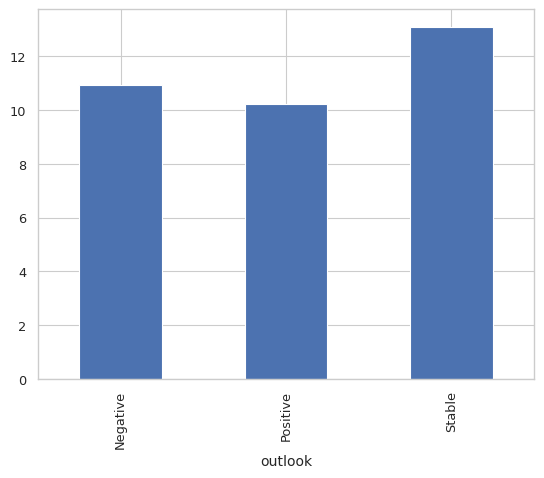

In [ ]:
moody = moody[moody["outlook"] != "Ratings withdrawn"]
moody.groupby("outlook")["rating_score"].mean().sort_values()
moody.groupby("outlook")["rating_score"].mean().plot(kind="bar")

In [ ]:
moody.groupby("outlook")["rating_score"].describe()

,count,mean,std,min,25%,50%,75%,max
outlook,,,,,,,,
Negative,14.0,10.928571,4.763068,6.0,7.0,9.5,14.75,19.0
Positive,17.0,10.235294,3.700159,6.0,7.0,10.0,12.00,19.0
Stable,102.0,13.098039,5.972726,2.0,8.0,13.0,18.00,22.0


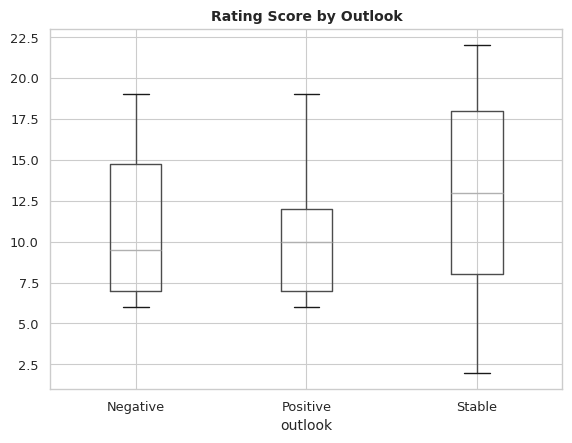

In [ ]:
import matplotlib.pyplot as plt
moody.boxplot(column="rating_score", by="outlook")
plt.title("Rating Score by Outlook")
plt.suptitle("")
plt.show()

This next cell loads the libraries used by every figure cell, fixes a single color palette and Seaborn theme so all charts share a consistent style, and defines three small helpers (clean_axes, label_chart, export) that the figure cells reuse.

In [ ]:
import seaborn as sns

PALETTE = {"navy": "#1f3b73", "red": "#b22234", "gray": "#4d4d4d", "green": "#2a7a3b"}

def setup_style():
    sns.set_theme(style="whitegrid", context="paper", font_scale=1.05)
    plt.rcParams["axes.titleweight"] = "bold"
    plt.rcParams["savefig.dpi"] = 200
    plt.rcParams["savefig.bbox"] = "tight"

def clean_axes(ax, sides=("top", "right")):
    for s in sides:
        ax.spines[s].set_visible(False)
    return ax

def label_chart(ax, title, xlabel, ylabel):
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)

def export(fig, name, download=True):
    fig.savefig(name)
    if download:
        files.download(name)

setup_style()

We plot the count of country-year observations in each Moody's rating bucket, color-coded as investment-grade (navy) or speculative-grade (red). The chart documents the class imbalance in the modeling sample, shows where the bulk of observations sit on the rating scale, and marks the Baa3/Ba1 boundary that becomes important when interpreting errors in the results section.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

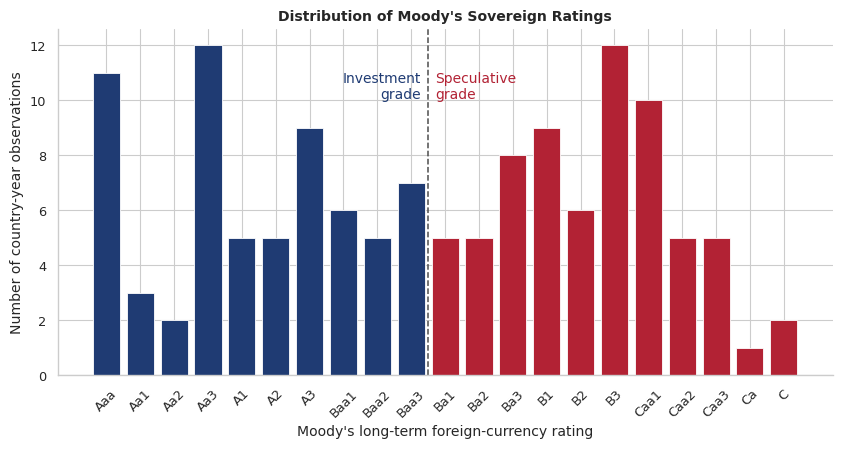

In [ ]:
RATING_ORDER = ["Aaa", "Aa1", "Aa2", "Aa3", "A1", "A2", "A3",
                "Baa1", "Baa2", "Baa3", "Ba1", "Ba2", "Ba3",
                "B1", "B2", "B3", "Caa1", "Caa2", "Caa3", "Ca", "C"]
IG_RATINGS = set(RATING_ORDER[:10])
IG_CUTOFF = len(IG_RATINGS) - 0.5

def rating_counts(df, col="rating"):
    return df[col].value_counts().reindex(RATING_ORDER).fillna(0).astype(int)

def bar_colors(labels):
    return [PALETTE["navy"] if r in IG_RATINGS else PALETTE["red"] for r in labels]

def annotate_grades(ax, y):
    ax.text(IG_CUTOFF - 0.2, y, "Investment\ngrade", ha="right", va="top", color=PALETTE["navy"], fontsize=10)
    ax.text(IG_CUTOFF + 0.2, y, "Speculative\ngrade", ha="left", va="top", color=PALETTE["red"], fontsize=10)

def plot_rating_distribution(counts):
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.bar(counts.index, counts.values, color=bar_colors(counts.index), edgecolor="white", linewidth=0.6)
    ax.axvline(IG_CUTOFF, color=PALETTE["gray"], linestyle="--", linewidth=1.1)
    annotate_grades(ax, counts.max() * 0.92)
    label_chart(ax, "Distribution of Moody's Sovereign Ratings", "Moody's long-term foreign-currency rating", "Number of country-year observations")
    ax.tick_params(axis="x", rotation=45)
    return clean_axes(ax).figure

counts = rating_counts(moody)
fig = plot_rating_distribution(counts)
export(fig, "fig1_rating_distribution.png")
plt.show()

We aggregate the rating scores by region and plot mean rating with one-standard-deviation error bars and per-region sample sizes. This surfaces the geographic structure in the data (Western Europe at the top, Africa/Middle East at the bottom) and motivates the discussion of whether the macro variables alone fully capture regional differences.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

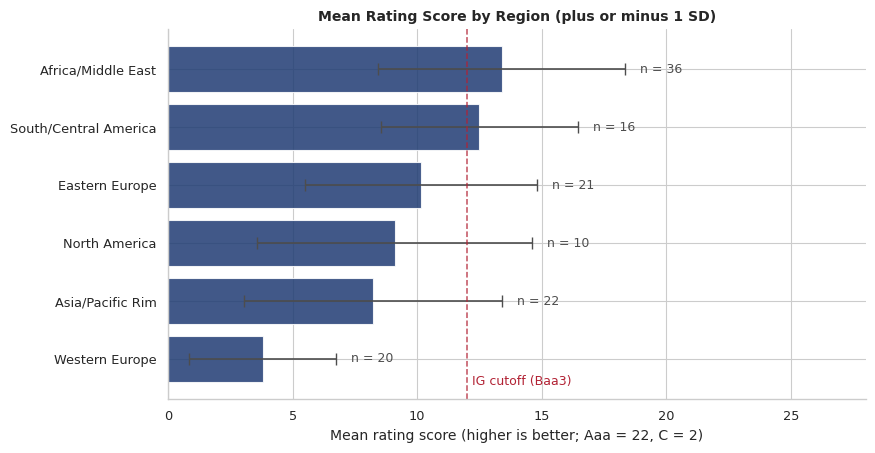

In [ ]:
def region_stats(df, col="rating_score", group="region"):
    return df.groupby(group)[col].agg(["mean", "std", "count"]).sort_values("mean")

def annotate_counts(ax, stats, pad=0.6):
    for i, (_, row) in enumerate(stats.iterrows()):
        x = row["mean"] + (row["std"] if pd.notna(row["std"]) else 0) + pad
        ax.text(x, i, f"n = {int(row['count'])}", va="center", fontsize=9, color=PALETTE["gray"])

def plot_region_distribution(stats):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    ax.barh(stats.index, stats["mean"], xerr=stats["std"], color=PALETTE["navy"], alpha=0.85, edgecolor="white", error_kw=dict(ecolor=PALETTE["gray"], capsize=4))
    ax.axvline(12, color=PALETTE["red"], linestyle="--", linewidth=1.1, alpha=0.8)
    ax.text(12.2, -0.45, "IG cutoff (Baa3)", color=PALETTE["red"], fontsize=9)
    annotate_counts(ax, stats)
    label_chart(ax, "Mean Rating Score by Region (plus or minus 1 SD)", "Mean rating score (higher is better; Aaa = 22, C = 2)", "")
    ax.set_xlim(0, 28)
    return clean_axes(ax).figure

stats = region_stats(clean_df)
fig = plot_region_distribution(stats)
export(fig, "fig2_region_distribution.png")
plt.show()

A boxplot of rating_score grouped by Moody's outlook (Negative, Stable, Positive) with a strip overlay showing the underlying observations and per-group sample sizes. The chart confirms that Stable is the modal outlook and that Positive and Negative outlooks cluster in the middle of the rating spectrum, which is consistent with agencies being unable to assign a directional outlook at the boundaries of the scale.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

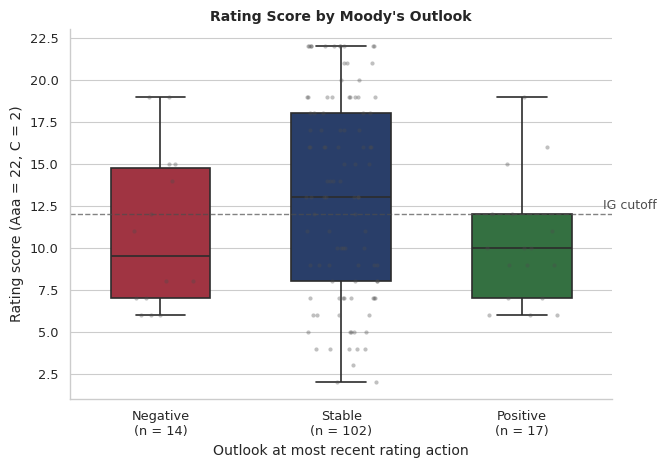

In [ ]:
OUTLOOK_ORDER = ["Negative", "Stable", "Positive"]
OUTLOOK_PALETTE = {"Negative": PALETTE["red"], "Stable": PALETTE["navy"], "Positive": PALETTE["green"]}

def filter_outlooks(df, col="outlook", keep=OUTLOOK_ORDER):
    return df[df[col].isin(keep)].copy()

def labeled_outlook_ticks(df, col="outlook"):
    counts = df[col].value_counts()
    return [f"{lab}\n(n = {counts.get(lab, 0)})" for lab in OUTLOOK_ORDER]

def plot_outlook_box(df):
    fig, ax = plt.subplots(figsize=(7, 4.8))
    sns.boxplot(data=df, x="outlook", y="rating_score", order=OUTLOOK_ORDER, hue="outlook", palette=OUTLOOK_PALETTE, legend=False, width=0.55, linewidth=1.2, fliersize=3, ax=ax)
    sns.stripplot(data=df, x="outlook", y="rating_score", order=OUTLOOK_ORDER, color=PALETTE["gray"], alpha=0.35, size=3, jitter=0.2, ax=ax)
    ax.axhline(12, color=PALETTE["gray"], linestyle="--", linewidth=1, alpha=0.7)
    ax.text(2.45, 12.3, "IG cutoff", color=PALETTE["gray"], fontsize=9)
    ax.set_xticks(range(len(OUTLOOK_ORDER)))
    ax.set_xticklabels(labeled_outlook_ticks(df))
    label_chart(ax, "Rating Score by Moody's Outlook", "Outlook at most recent rating action", "Rating score (Aaa = 22, C = 2)")
    return clean_axes(ax).figure

df_outlook = filter_outlooks(moody)
fig = plot_outlook_box(df_outlook)
export(fig, "fig3_outlook_boxplot.png")
plt.show()

Collapsing Moody's 21 alphanumeric notches into 8 broad letter tiers (Aaa through Ca-C) gives a more legible view of the sample's class distribution than the full bar chart. The plot also marks the investment-grade boundary so the reader can see at a glance how the sample splits between IG and speculative-grade sovereigns.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

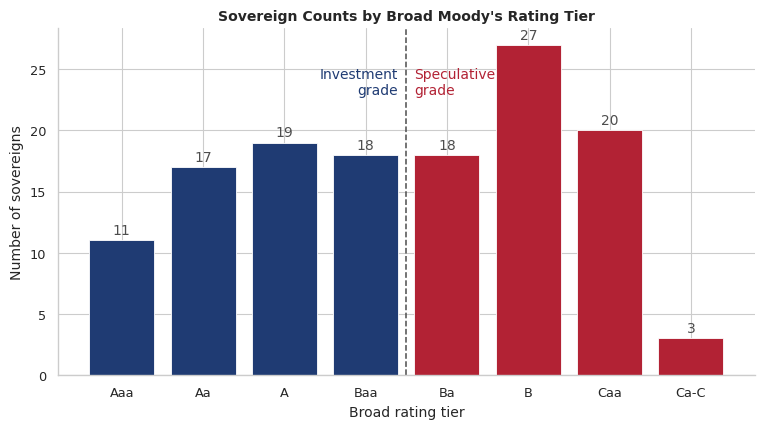

In [ ]:
TIER_MAP = {"Aaa": "Aaa", "Aa1": "Aa", "Aa2": "Aa", "Aa3": "Aa",
            "A1": "A", "A2": "A", "A3": "A",
            "Baa1": "Baa", "Baa2": "Baa", "Baa3": "Baa",
            "Ba1": "Ba", "Ba2": "Ba", "Ba3": "Ba",
            "B1": "B", "B2": "B", "B3": "B",
            "Caa1": "Caa", "Caa2": "Caa", "Caa3": "Caa",
            "Ca": "Ca-C", "C": "Ca-C"}
TIER_ORDER = ["Aaa", "Aa", "A", "Baa", "Ba", "B", "Caa", "Ca-C"]
IG_TIERS = {"Aaa", "Aa", "A", "Baa"}

def tier_counts(df, col="rating"):
    return df[col].map(TIER_MAP).value_counts().reindex(TIER_ORDER).fillna(0).astype(int)

def tier_colors(tiers):
    return [PALETTE["navy"] if t in IG_TIERS else PALETTE["red"] for t in tiers]

def annotate_bar_heights(ax, values):
    for bar, v in zip(ax.patches, values):
        ax.text(bar.get_x() + bar.get_width() / 2, v + 0.5, str(int(v)), ha="center", fontsize=10, color=PALETTE["gray"])

def plot_tier_distribution(counts):
    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.bar(counts.index, counts.values, color=tier_colors(counts.index), edgecolor="white", linewidth=0.6)
    annotate_bar_heights(ax, counts.values)
    ax.axvline(3.5, color=PALETTE["gray"], linestyle="--", linewidth=1.1)
    ax.text(3.4, counts.max() * 0.85, "Investment\ngrade", ha="right", color=PALETTE["navy"], fontsize=10)
    ax.text(3.6, counts.max() * 0.85, "Speculative\ngrade", ha="left", color=PALETTE["red"], fontsize=10)
    label_chart(ax, "Sovereign Counts by Broad Moody's Rating Tier", "Broad rating tier", "Number of sovereigns")
    return clean_axes(ax).figure

counts = tier_counts(moody)
fig = plot_tier_distribution(counts)
export(fig, "fig9_tier_distribution.png")
plt.show()

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

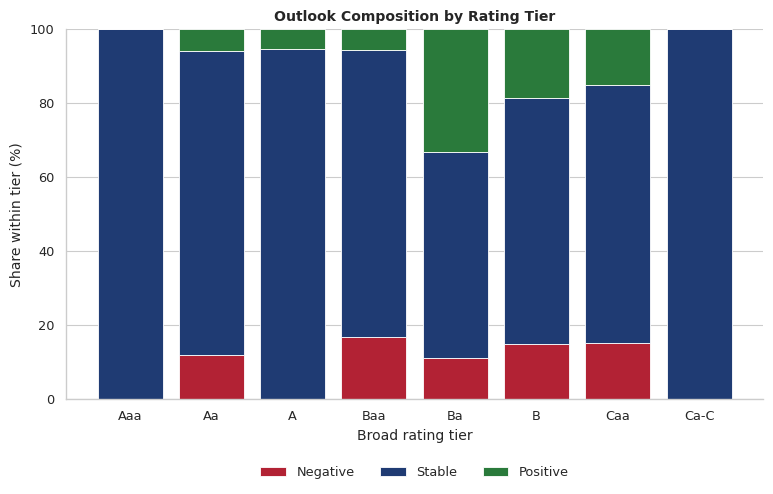

In [ ]:
def add_tier_column(df, source="rating", target="tier"):
    out = df.copy()
    out[target] = out[source].map(TIER_MAP)
    return out

def outlook_share_by_tier(df, tier_col="tier", outlook_col="outlook"):
    sub = df[df[outlook_col].isin(OUTLOOK_ORDER)]
    tab = pd.crosstab(sub[tier_col], sub[outlook_col], normalize="index")
    return tab.reindex(index=TIER_ORDER, columns=OUTLOOK_ORDER).fillna(0) * 100

def stack_outlooks(ax, tab):
    bottom = np.zeros(len(tab))
    for outlook in OUTLOOK_ORDER:
        ax.bar(tab.index, tab[outlook], bottom=bottom, label=outlook, color=OUTLOOK_PALETTE[outlook], edgecolor="white", linewidth=0.6)
        bottom += tab[outlook].values

def plot_outlook_by_tier(tab):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    stack_outlooks(ax, tab)
    label_chart(ax, "Outlook Composition by Rating Tier", "Broad rating tier", "Share within tier (%)")
    ax.set_ylim(0, 100)
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=3, frameon=False)
    return clean_axes(ax).figure

moody = add_tier_column(moody)
share = outlook_share_by_tier(moody)
fig = plot_outlook_by_tier(share)
export(fig, "fig10_outlook_by_tier.png")
plt.show()